In [13]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from optiland import optic
from autoachromat.optiland_bridge.builder import AGFMaterial
from autoachromat.glass_reader import load_catalog
from autoachromat.optics import refractive_index

# Load glass catalog
glasses = load_catalog([os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'catalogs', 'SCHOTT.AGF'))])
glass_map = {g.name: g for g in glasses}

sf53 = glass_map['SF53']
nfk56 = glass_map['N-FK56']

mat_sf53 = AGFMaterial(sf53.formula_id, sf53.cd, 'SF53')
mat_nfk56 = AGFMaterial(nfk56.formula_id, nfk56.cd, 'N-FK56')

In [16]:
cemented_doublet = optic.Optic()

cemented_doublet.add_surface(index=0, radius=float("inf"), thickness=float("inf"))  # OBJ

cemented_doublet.add_surface(index=1, radius=76.447, thickness=2.200, material=mat_sf53, is_stop=True)
cemented_doublet.add_surface(index=2, radius=57.399, thickness=7.927, material=mat_nfk56)
cemented_doublet.add_surface(index=3, radius=-788.523, thickness=192.657)           # air
cemented_doublet.add_surface(index=4)                                              # IMG

cemented_doublet.set_aperture(aperture_type="EPD", value=50)

cemented_doublet.set_field_type(field_type="angle")
cemented_doublet.add_field(y=0)

cemented_doublet.add_wavelength(value=0.8)
cemented_doublet.add_wavelength(value=1, is_primary=True)
cemented_doublet.add_wavelength(value=1.2)

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

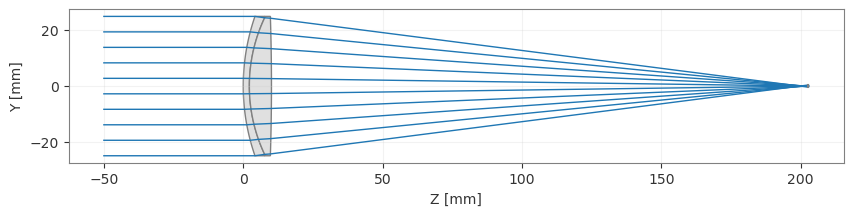

In [17]:
cemented_doublet.draw(num_rays=10)